In [1]:
from src.preprocessing import *
# from src.your_part_usage_example import main
from src.sdt import SDT
from src.dbdt import DBDT_SGD
from src.pdsca import DBDTComTrainer
from src.baselines import get_baseline_models
from src.evaluation import *
from hmeasure import h_score
import torch
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Data Preprocessing

- Loaded the Kaggle credit-card fraud dataset and mapped labels from {0,1} to {-1,+1}.
- Used stratified train/test and train/validation splits to preserve class imbalance.
- Standardized Amount and Time using scaler fit on train only.
- Applied `IQR` outlier filtering on training data only (Amount, Time).
- Applied `SMOTE` on filtered training data only to rebalance classes.
- Generated `t-SNE` plots before/after `SMOTE` for class-separation visualization.

sample_size: 20000


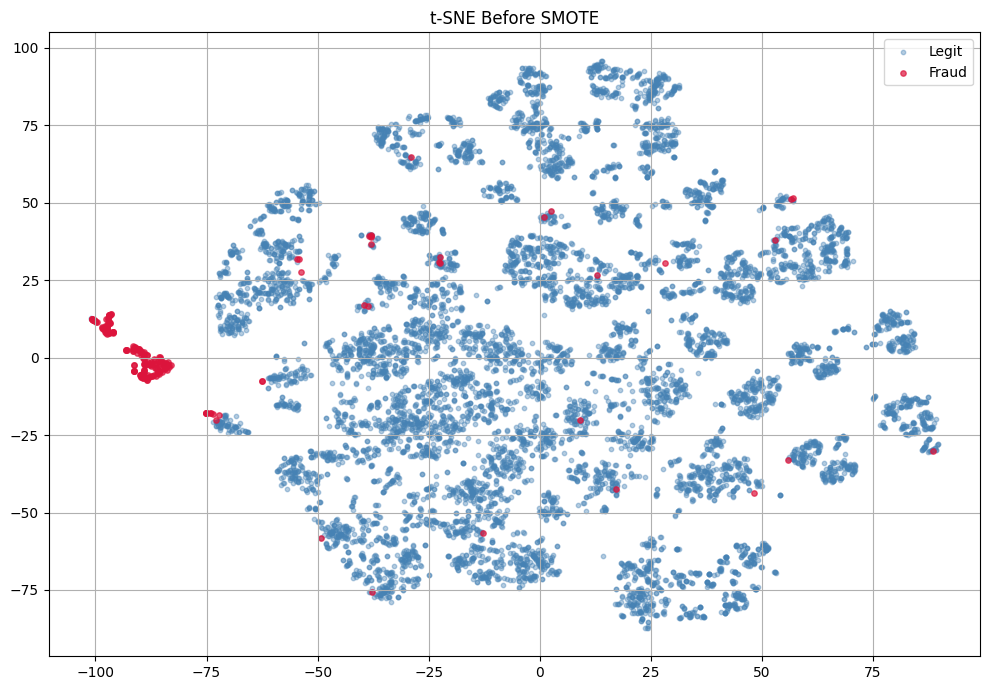

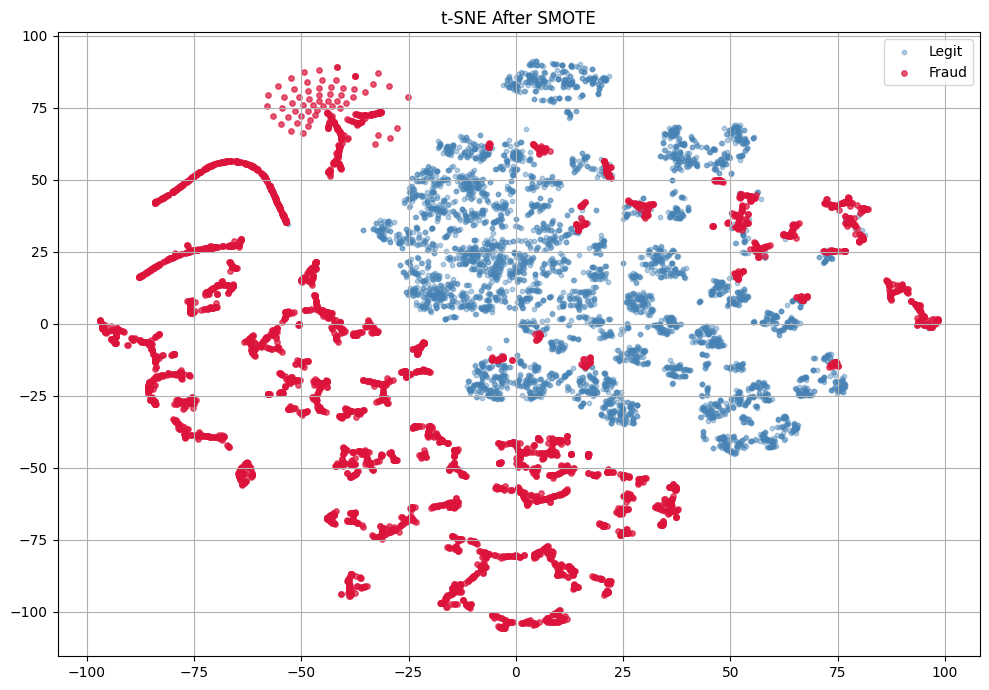

=== Dataset Size Levels ===
Full dataset          : X=284,807, y=284,807 | class={np.int64(1): 284315, np.int64(-1): 492}
Subset dataset        : X=20,000, y=20,000 | class={np.int64(1): 19508, np.int64(-1): 492}
Train split           : X=10,048, y=10,048 | class={np.int64(1): 9815, np.int64(-1): 233}
Validation split      : X=3,750, y=3,750 | class={np.int64(1): 3658, np.int64(-1): 92}
Test split            : X=5,000, y=5,000 | class={np.int64(1): 4877, np.int64(-1): 123}
Train after IQR       : X=10,048, y=10,048 | class={np.int64(1): 9815, np.int64(-1): 233}
Train after SMOTE     : X=19,630, y=19,630 | class={np.int64(1): 9815, np.int64(-1): 9815}

SMOTE growth factor   : 1.95x


In [2]:
# Mubaraq
sample_size = 20000
X, y = load_data()
X_full, y_full = X, y
import collections
# print(collections.Counter(y))
if sample_size:
    print(f'sample_size: {sample_size}')
    # separate by class
    fraud_idx = np.where(y == -1)[0]
    legit_idx = np.where(y == 1)[0]

    # take all fraud + random legit
    legit_sample = np.random.choice(legit_idx, size=sample_size - len(fraud_idx), replace=False)
    idx = np.concatenate([fraud_idx, legit_sample])
    np.random.shuffle(idx)

    X = X.iloc[idx]
    y = y[idx]
    
X_train, X_test, y_train, y_test = test_train_split(X, y)
X_train, X_val, y_train, y_val = train_valid_split(X_train, y_train)
X_train_iqr, y_train_iqr = interquatile_range(X_train, y_train)
plot_tsne(X=X_train_iqr, y=y_train_iqr, title="t-SNE Before SMOTE", sample_size=sample_size//2 if sample_size else 1000) 
unique_before, counts_before = np.unique(y_train, return_counts=True)


X_train, y_train = apply_smote(X_train_iqr, y_train_iqr) # resampled
feature_size_smote = X_train.size
# print(f"After SMOTE: {feature_size_smote}")
plot_tsne(X=X_train, y=y_train, title="t-SNE After SMOTE", sample_size=sample_size//2 if sample_size else 1000)
unique_after, counts_after = np.unique(y_train, return_counts=True)

print_dataset_size_levels(
    X_full, y_full,            # original/full before subset (replace if needed)
    X_subset=X, y_subset=y,       
    X_train=X_train_iqr, y_train=y_train_iqr,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    X_train_iqr=X_train_iqr, y_train_iqr=y_train_iqr, 
    X_train_smote=X_train, y_train_smote=y_train
)


# SDT (Mubaraq)
 
**1. Sigmoid (inner node activation)**
 
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
 
Each inner node MLP outputs a routing probability $p_i \in (0, 1)$ via sigmoid.
 
**2. Left / right path selection**
 
$$
I^l_i + I^r_i = 1
$$
 
Where $I^r_i = 1$ if $p_i > 0.5$ (go right), $I^l_i = 1$ if $p_i < 0.5$ (go left).
 
**3. Leaf node output (binary case)**
 
For binary classification with labels $y \in \{-1, +1\}$, each leaf outputs a scalar $\varphi_\ell \in \mathbb{R}$.
 
In the general multi-class case the softmax is applied:
 
$$
Q^{\ell}_k = \frac{\exp(\varphi^{\ell}_k)}{\sum_{k'} \exp(\varphi^{\ell}_{k'})}
$$
 
Where $\varphi^\ell$ is the learned parameter vector of leaf $\ell$ and $k$ indexes the class.
  
**4. Path probability**
 
$$
\pi_\ell(x \mid \Theta) = \prod_{j < \ell} d_j(x;\Theta_j)^{I^r_j} \cdot (1 - d_j(x;\Theta_j))^{I^l_j}
$$
 
Where:
- $d_j(x; \Theta_j)$ is the sigmoid output of inner node $j$ — i.e. $p_j$
- $I^r_j = 1$ if node $j$ routes right on the path to leaf $\ell$, else $0$
- $I^l_j = 1$ if node $j$ routes left on the path to leaf $\ell$, else $0$
- The product runs over all inner nodes $j$ on the root-to-leaf-$\ell$ path
 
 
**5. SDT predicted output**
 
$$
\hat{y}(x) = \sum_{\ell} \pi_\ell(x \mid \Theta) \cdot \varphi_\ell
$$
 
The final score $h(x) \in \mathbb{R}$. Prediction is the sign:
 
$$
\hat{y} = \text{sign}(h(x)) \in \{-1, +1\}
$$

**6. Tree dimensions**
 
For a tree of depth $d$:
 
$$
\text{inner nodes} = 2^d - 1 \qquad \text{leaf nodes} = 2^d
$$
 


### Test SDT

In [3]:
# This is to ensure sdt is running
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t, X_test_t, y_train_t, y_test_t=torch_cast(X_train, X_test, y_train, y_test, device) # allows for torch shaping
_, X_val_t, _, y_val_t=torch_cast(X_train, X_val, y_train, y_val, device) # allows for torch shaping

"""SDT is not evaluated in the paper. It is not trained on anything, therefore no evaluation. [untrained weights]"""
model = SDT(input_dim=30, depth=4, hidden_dim=30).to(device)
output, path_probs, node_outputs, node_reach = model.forward(X_train_t)
preds =model.predict(X_train_t)
print(preds.shape)
print(preds.unique())


torch.Size([19630])
tensor([-1.], device='cuda:0')


## Deep Boosting 
**7. Boosting exponential loss**
 
$$
L = \sum_i \exp(-y_i \cdot F(x_i))
$$

 
Where $y_i \in \{-1, +1\}$ and $F(x_i)$ is the ensemble score. Requires $\{-1, +1\}$ labels — loss is asymmetric with $\{0, 1\}$.
 
 
**8. Final ensemble prediction**
 
$$
F_T(x) = \sum_{t=1}^{T} \alpha_t \cdot h_t(x)
$$
 
Where:
- $h_t(x)$ is the output of the $t$-th SDT weak learner
- $\alpha_t$ is the boosting weight of tree $t$
- $T$ is the total number of trees
 

In [4]:

print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 4070 Laptop GPU


### Model

In [5]:
epochs = 30
batch_size = 256
T = 20
model = DBDT_SGD(T=T, input_dim=30, depth=4, hidden_dim=30, lr=0.01, device= device)


### Fit

In [6]:
## DBDT_SGD fit
h = model.fit(X_train_t,  y_train_t, epochs=epochs, batch_size=batch_size)
print(h.device)

Training DBDT: 100%|██████████| 30/30 [31:38<00:00, 63.29s/it, loss=410.2352] 


cuda


## Metrics(DBDT SGD)
Metrics include produces evaluation for:
- AUC, F1, Precision, Recall, and H-Measure.
- Visuals for Confusion matrix and ROCs

In [7]:
print(f"epochs={epochs}, batch_size={batch_size}, T={T}")

epochs=30, batch_size=256, T=20


### Train Evaluation

no. of samples 19630 || {np.float32(1.0): 9815, np.float32(-1.0): 9815}
AUC:       0.9984
F1:        0.9493
Precision: 0.9987
Recall:    0.9045
H-measure: 0.8475


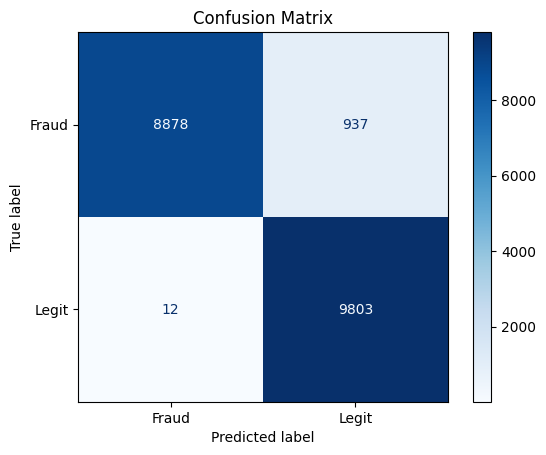

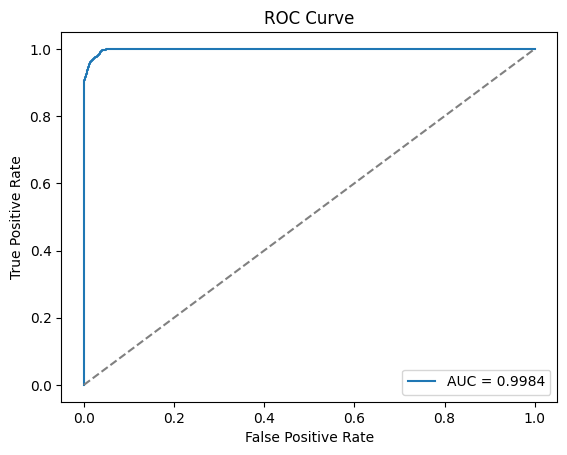

In [8]:
train_metrics = evaluate_binary(y_train_t, model.predict_score(X_train_t), threshold=0.8, print_ = True)

### Validaiton Evaluations
Using threshold optimization to get best threshold that maximizws recall (So we miss less fraud)

Best threshold=0.380 | precision=0.8876 | recall=0.8587 | f1=0.8729


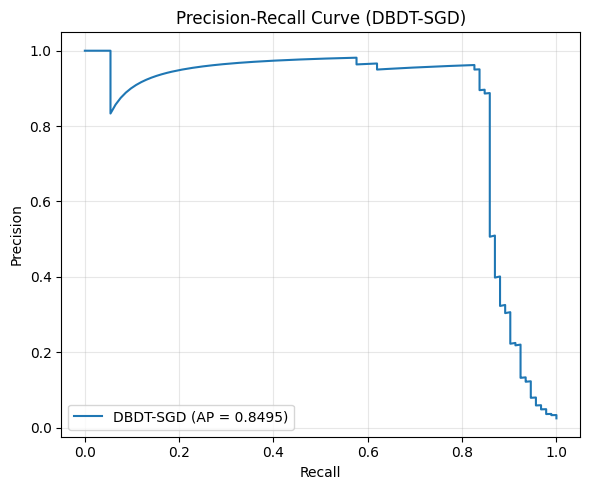

In [9]:

    
thresholds = np.arange(0.05, 0.95, 0.01)

def threshold_optimization(model, X_val_t, y_val_t, thresholds, recall_floor=0.95):
    candidates = []
    scores =model.predict_score(X_val_t)
    for t in thresholds:
        m = evaluate_binary(y_val_t, scores, threshold=t, print_=False)
        if m["recall"] >= recall_floor:
            candidates.append((t, m["precision"], m["f1"], m["recall"]))
    if not candidates:
        # thisis a  fallback maximize recall if floor not met
        all_scores = []
        for t in thresholds:
            m = evaluate_binary(y_val_t,scores , threshold=t, print_=False)
            all_scores.append((t, m["recall"], m["precision"], m["f1"]))
        best_t = max(all_scores, key=lambda x: (x[1], x[2], x[3]))[0]
        return best_t
    best_t, best_p, best_f1, best_r = max(candidates, key=lambda x: (x[1], x[2], x[3]))
    print(f"Best threshold={best_t:.3f} | precision={best_p:.4f} | recall={best_r:.4f} | f1={best_f1:.4f}")
    return best_t

best_threshold = threshold_optimization(model, X_val_t, y_val_t, thresholds=thresholds, recall_floor=0.85)
precision_recall_curve(X_val_t, y_val_t, model=model)

### Test Evaluations

no. of samples 5000 || {np.float32(1.0): 4877, np.float32(-1.0): 123}
AUC:       0.9726
F1:        0.8571
Precision: 0.8607
Recall:    0.8537
H-measure: 0.7774


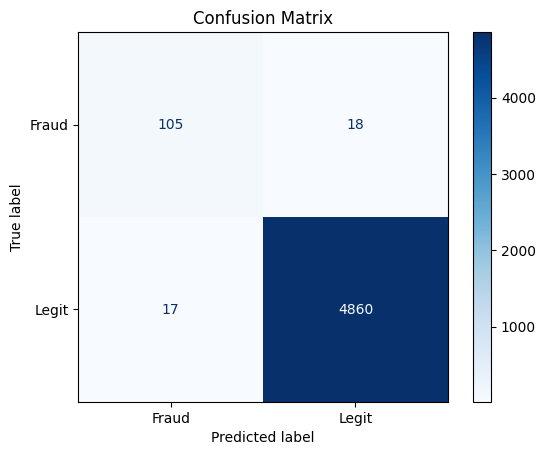

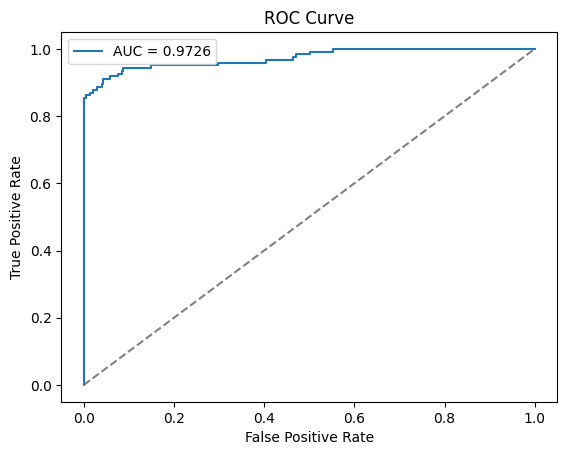

In [10]:


test_metrics = evaluate_binary(y_test_t, model.predict_score(X_test_t), threshold=best_threshold)


# DBDT-COM (Darsh)

In [11]:
trainer = DBDTComTrainer(
    model=model,
    eta1=1e-3,
    batch_size=batch_size,
    device=device,
)

trainer.fit(X_train_t, y_train_t, epochs=epochs)


Training DBDT: 100%|██████████| 30/30 [14:57<00:00, 29.92s/it]


## Evaluation

In [12]:

# Model learns fraud=-1, legit=+1.
# So raw scores are LOWER for fraud.
raw_scores = trainer.predict_scores(X_test_t)

# Flip sign so HIGHER score means fraud/positive class
fraud_scores = -raw_scores

# Convert to probabilities for H-measure / metrics
test_scores = 1 / (1 + np.exp(-fraud_scores))

y_test_bin = np.where(y_test_t.detach().cpu().numpy() == -1, 1, 0)

print("\nDBDT-Com test metrics:\n", compute_metrics(y_test_bin, test_scores))


DBDT-Com test metrics:
 FoldResult(auc=0.9465735133053608, h_measure=0.7735708726583816, f1=0.3593220338983051, precision=0.22698072805139186, recall=0.8617886178861789)


## Baselines

In [ ]:

baseline_models = get_baseline_models(random_state=42)
baseline_summary, _ = run_stratified_10fold_cv(baseline_models, X_train, y_train)
print("\nBaseline CV summary:\n", baseline_summary)


Baseline CV summary:
     model  auc_mean   auc_std  h_measure_mean  h_measure_std   f1_mean  \
2     mlp  0.999840  0.000103        0.993522       0.003547  0.997153   
1      rf  0.997184  0.000944        0.939584       0.010210  0.968557   
0  logreg  0.989694  0.001968        0.884345       0.010677  0.951185   

     f1_std  precision_mean  precision_std  recall_mean  recall_std  
2  0.001268        0.995334       0.001981     0.998981    0.001019  
1  0.003384        0.996776       0.002082     0.941924    0.006957  
0  0.004502        0.982944       0.003525     0.921444    0.007354  


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
  File "/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _,

Better than paper:
hyper parameters: T = 40; batch_size = 256; epochs = 30



AUC:       0.9719
F1:        0.8889
Precision: 0.9804
Recall:    0.8130
H-measure: 0.7991